In [10]:
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import cv2
import matplotlib.pyplot as plt
import os

In [14]:
dataset_path ="/content/drive/MyDrive/DIP-Dataset/images"

In [15]:
processed_count = 0

for image_name in sorted(os.listdir(dataset_path)):

    image_path = os.path.join(dataset_path, image_name)

    image = cv2.imread(image_path)

    if image is None:
        continue

    processed_count += 1

    print(f"Processed {processed_count}: {image_name}")

Processed 1: Cars0.png
Processed 2: Cars1.png
Processed 3: Cars10.png
Processed 4: Cars100.png
Processed 5: Cars101.png
Processed 6: Cars102.png
Processed 7: Cars103.png
Processed 8: Cars104.png
Processed 9: Cars105.png
Processed 10: Cars106.png
Processed 11: Cars107.png
Processed 12: Cars108.png
Processed 13: Cars109.png
Processed 14: Cars11.png
Processed 15: Cars110.png
Processed 16: Cars111.png
Processed 17: Cars112.png
Processed 18: Cars113.png
Processed 19: Cars114.png
Processed 20: Cars115.png
Processed 21: Cars116.png
Processed 22: Cars117.png
Processed 23: Cars118.png
Processed 24: Cars119.png
Processed 25: Cars12.png
Processed 26: Cars120.png
Processed 27: Cars121.png
Processed 28: Cars122.png
Processed 29: Cars123.png
Processed 30: Cars124.png
Processed 31: Cars125.png
Processed 32: Cars126.png
Processed 33: Cars127.png
Processed 34: Cars128.png
Processed 35: Cars129.png
Processed 36: Cars13.png
Processed 37: Cars130.png
Processed 38: Cars131.png
Processed 39: Cars132.png
Pro

In [16]:
# Convert BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# 1. Grayscale Conversion

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# 2. Bilateral Filtering
# Reduces noise while preserving edges

bilateral = cv2.bilateralFilter(gray, 11, 17, 17)

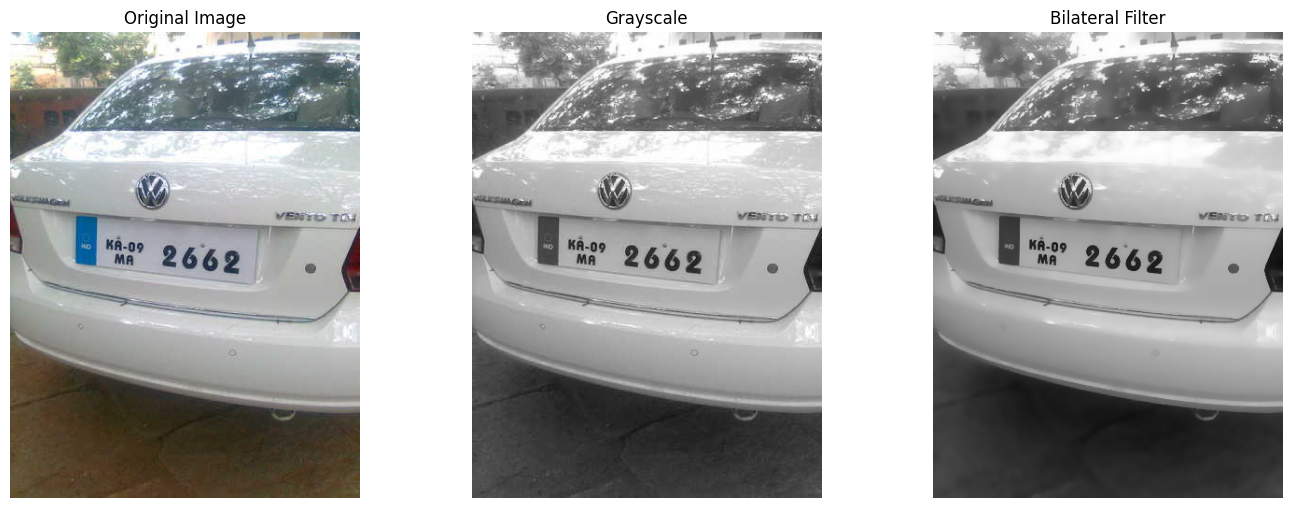

In [17]:
plt.figure(figsize=(14, 10))

# Original Image
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

# Grayscale Image
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# Bilateral Filtered Image
plt.subplot(2, 3, 3)
plt.imshow(bilateral, cmap="gray")
plt.title("Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# 3. Edge Detection (Canny)

edges = cv2.Canny(bilateral, 100, 200)

In [19]:
# 4. Morphological Closing (Connect nearby edges into one plate region)

# Wide horizontal rectangular kernel
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 5))

# Apply morphological closing
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

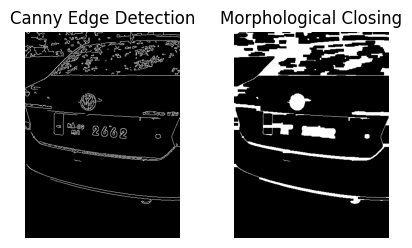

In [20]:
# Edge Detection
plt.subplot(2, 3, 4)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

# Morphological Closing
plt.subplot(2, 3, 5)
plt.imshow(closed, cmap="gray")
plt.title("Morphological Closing")
plt.axis("off")

plt.tight_layout()
plt.show()